In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ⬅️ Run this first to upload your files into /content/
from google.colab import files
uploaded = files.upload()  # choose: llm_cache.jsonl AND your messages .xlsx
list(uploaded.keys())


KeyboardInterrupt: 

In [ ]:
import pandas as pd

# Replace the URL with the public share link of your Google Sheet
google_sheet_url = "https://docs.google.com/spreadsheets/d/1uYgCm-TUXwCc5k3V1RnUj-O9dUHSKN0Fv7eEh4UiV4Q/export?format=xlsx" # Changed format to xlsx for read_excel

# Read the "messages1307" sheet
messages_df = pd.read_excel(google_sheet_url, sheet_name="messages1307")
print("messages_df loaded:")
display(messages_df.head())

# Read the "Conversations" sheet
conversations_df = pd.read_excel(google_sheet_url, sheet_name="Conversations")
print("\nconversations_df loaded:")
display(conversations_df.head())

# Read the "responses1307" sheet
responses_df = pd.read_excel(google_sheet_url, sheet_name="responses1307")
print("\nresponses_df loaded:")
display(responses_df.head())

messages_df loaded:


,message_id,conversation_id,messages translated,message,message_src,timestamp,persona_id,group typer,message source
0,3057,939,hello,hello,user,2025-04-22 21:20:34,1,Experiment Group,user
1,3058,939,If you picture a library as anything other tha...,If you picture a library as anything other tha...,assistant,2025-04-22 21:20:37,1,Experiment Group,Taylor
2,3059,939,big show,big show,user,2025-04-22 21:23:08,2,Experiment Group,user
3,3060,939,"To design a library as a venue for a big show,...","To design a library as a venue for a big show,...",assistant,2025-04-22 21:23:11,2,Experiment Group,Alex
4,3061,939,a show that is related to one of the books in ...,a show that is related to one of the books in ...,user,2025-04-22 21:23:48,1,Experiment Group,user



conversations_df loaded:


,user_id,conversation_id,persona_id,timestamp,Column 5
0,191,635,2,NaT,Experiment Group
1,336,935,4,2025-04-22 13:28:57,Control Group
2,337,937,2,2025-04-22 17:53:34,Experiment Group
3,338,939,2,2025-04-22 18:20:25,Experiment Group
4,339,941,2,2025-04-22 19:38:00,Experiment Group



responses_df loaded:


,id,user_id,conversation_id,Group type,submission_time,solutions_detail,Solution_detail_english,age,gender,academic_background,...,big5_q8,big5_q9,big5_q10,big5_q11,big5_q12,big5_q13,big5_q14,big5_q15,gift_email,additional_comments
0,10,346,955,Control Group,2025-04-22 20:14:22,סרטוני מדיה דיגיטלית במיוחד טיקטוק ואינסטגרם. ...,Digital media videos especially Tiktok and Ins...,29,Female,Design,...,2,1,2,5,4,4,3,3,litalbamnulker@gmail.com,NaN
1,11,341,945,Experiment Group,2025-04-22 20:14:47,מערכת מבוססות תחרויות המקנות הזדמנויות עבודה ל...,A system based on competitions that provide jo...,30,Male,Engineering,...,2,2,4,3,5,5,4,4,alonzam@gmail.com,NaN
2,12,337,937,Experiment Group,2025-04-22 20:15:50,בשביל למשוך צעירים לספריות צריך משהוא יעניין א...,"In order to attract young people to libraries,...",37,Male,Engineering,...,1,1,3,3,4,5,3,5,mohamedkh888@gmail.com,NaN
3,13,345,953,Experiment Group,2025-04-22 20:16:31,gaming corner \nelectronic books,gaming corner \nelectronic books,22,Male,Engineering,...,3,4,4,4,2,5,5,4,yousef.a.you2@gmail.com,NaN
4,14,344,951,Experiment Group,2025-04-22 20:17:17,To turn the libraries into a space for in-pers...,To turn the libraries into a space for in-pers...,33,Male,Design,...,3,3,2,4,5,5,2,5,yaniv.so2@gmail.com,NaN


In [ ]:
!pip install -q --upgrade openai==1.40.0 pandas==2.2.2 tqdm tenacity statsmodels scikit-learn openpyxl xlsxwriter

In [ ]:
!pip -q install --upgrade openai
# Then Runtime → Restart, and run notebook from the top.


In [ ]:
!pip -q install choix
!pip -q install pingouin


In [ ]:
!pip -q install --upgrade "numpy>=2.0,<2.2" "scipy>=1.13,<1.15" "choix>=0.4.1"
# IMPORTANT: after this finishes, do: Runtime → Restart runtime


In [ ]:
import numpy, scipy, choix, pingouin
print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)
print("pingouin:", pingouin.__version__)
print("choix:", choix.__version__)


NumPy: 2.1.3
SciPy: 1.14.1
pingouin: 0.5.5


AttributeError: module 'choix' has no attribute '__version__'

In [ ]:
import os, getpass

# If you already set it in Colab "Secrets", you can skip this cell.
os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key (starts with sk-): ")

# Basic sanity: don’t proceed if missing/placeholder
k = os.getenv("OPENAI_API_KEY", "")
assert k and k != "YOUR_API_KEY_HERE" and k.startswith("sk-"), "OPENAI_API_KEY not set correctly"
print("Key set ✔︎ ending with:", k[-6:])


Enter your OpenAI API key (starts with sk-): ··········
Key set ✔︎ ending with: OCJUsA


In [ ]:
from openai import OpenAI
client = OpenAI()  # reads OPENAI_API_KEY from env

resp = client.chat.completions.create(
    model="gpt-4o-mini",  # or any chat-capable model you have access to
    messages=[{"role":"user","content":"Return only JSON: {\"ok\": true}"}],
    temperature=0
)
print(resp.choices[0].message.content)  # expect {"ok": true}


```json
{"ok": true}
```


In [ ]:
import os, json, math, re, random, numpy as np, pandas as pd
from typing import Dict, Any, List, Tuple
from datetime import datetime
from tqdm.auto import tqdm

# ==== I/O ====
XLSX_PATH   =  "https://docs.google.com/spreadsheets/d/1uYgCm-TUXwCc5k3V1RnUj-O9dUHSKN0Fv7eEh4UiV4Q/export?format=xlsx"   # <— change if needed
SHEET_NAME  = "messages1307"                                  # <— change if needed
OUT_DIR     = "/content/creativity_out"
os.makedirs(OUT_DIR, exist_ok=True)


# ==== Models (Approach 2 backbone) ====
MODEL_JUDGE       = "gpt-4.1-2025-04-14" #"gpt-5-2025-08-07"        # Holistic 7-dim + evidence quotes
MODEL_EXTRACT     = "gpt-4.1-2025-04-14" #"o4-mini-2025-04-16"   # Idea extraction & category induction
MODEL_PAIRWISE    = "gpt-4.1-2025-04-14" #"o4-mini-2025-04-16"   # Pairwise calibration (upgrade)
TEMPERATURE       = 0.0
SEED              = 7

# ==== Personas (Approach 1 rubric lenses) ====
PERSONAS = {
    "design_thinking": "Design Thinking Expert",
    "social_psych":    "Social Psychology Researcher",
    "hci":             "HCI Expert",
    "ethics":          "Philosopher/Ethicist",
    "innovation":      "Innovation/Strategy Expert"
}

# ==== Execution knobs ====
DRY_RUN                  = False   # True => fabricate outputs (for a quick plumbing & sanity-check)
MAX_IDEAS_PER_CHUNK      = 40
MAX_CATEGORIES           = 8
CHUNK_CHAR_MAX           = 12000   # for extraction/categorization only; judging uses long-context model
CHUNK_OVERLAP            = 800
PAIRWISE_SAMPLE_FRACTION = 0.10    # 10% of all unique pairs (cap later)
PAIRWISE_MAX_PAIRS       = 200     # hard cap
ANCHOR_FRACTION          = 0.05    # 5% of conversations become anchors
RNG                      = random.Random(SEED)


In [ ]:
def load_messages(path_xlsx: str, sheet: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Standardizes the sheet into:
      df_std:   tidy rows: conversation_id, timestamp, speaker_role, message_text, group
      agg_user: one row per conversation with user-only transcript
    """
    df = pd.read_excel(path_xlsx, sheet_name=sheet)
    cols = {c.lower(): c for c in df.columns}

    def pick(*names, contains=None, default=None):
        for n in names:
            if n in cols: return cols[n]
        if contains:
            for k in cols:
                if contains in k: return cols[k]
        return default

    col_conv   = pick("conversation_id", contains="convers")
    col_time   = pick("timestamp", "time", contains="time")
    col_role   = pick("message source", "role", contains="role")
    col_msg    = pick("messages translated", "message", "content", "text", contains="message")
    col_group  = pick("group typer", "group", default=None)

    if col_conv is None or col_role is None or col_msg is None:
        raise ValueError(f"Missing core columns. Found: {list(df.columns)}")

    # Standardize
    if col_time in df.columns:
        ts = pd.to_datetime(df[col_time], errors="coerce")
    else:
        ts = pd.Series(pd.RangeIndex(len(df)), name="timestamp")

    role_map = lambda x: "user" if isinstance(x, str) and x.strip().lower()=="user" else "ai"
    group_map = lambda x: (x.lower() if isinstance(x,str) else "unknown")

    df_std = pd.DataFrame({
        "conversation_id": df[col_conv],
        "timestamp": ts,
        "speaker_role": df[col_role].apply(role_map),
        "message_text": df[col_msg].astype(str),
        "group": df[col_group].apply(group_map) if col_group in df.columns else "unknown"
    }).sort_values(["conversation_id","timestamp"]).reset_index(drop=True)

    # Build user-only transcript (indexed lines for quoting evidence)
    user_only = df_std[df_std["speaker_role"]=="user"].copy()
    agg_user = (
        user_only.groupby("conversation_id")
        .apply(lambda g: "\n".join([f"[{i}] {r['message_text']}" for i,(_,r) in enumerate(g.iterrows())]))
        .reset_index(name="user_transcript")
    )
    groups = df_std.groupby("conversation_id")["group"].first().reset_index()
    agg_user = agg_user.merge(groups, on="conversation_id", how="left")
    return df_std, agg_user

df_std, agg_user = load_messages(XLSX_PATH, SHEET_NAME)
print(f"Loaded {len(df_std)} rows; {len(agg_user)} conversations.")
display(df_std.head(3))
display(agg_user.head(3))


Loaded 3170 rows; 101 conversations.


/tmp/ipython-input-4167933603.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: "\n".join([f"[{i}] {r['message_text']}" for i,(_,r) in enumerate(g.iterrows())]))


,conversation_id,timestamp,speaker_role,message_text,group
0,635,2025-06-28 16:59:39,user,Local libraries are seeing a decline in visito...,experiment group
1,635,2025-06-28 16:59:45,ai,Imagine the library not as a quiet book wareho...,experiment group
2,635,2025-06-28 17:00:56,user,"that are some great idea, what do you think Alex?",experiment group


,conversation_id,user_transcript,group
0,635,[0] Local libraries are seeing a decline in vi...,experiment group
1,937,[0] Mix of computers and books like coffee con...,experiment group
2,939,[0] hello\n[1] big show\n[2] a show that is re...,experiment group


In [ ]:
import hashlib
from tenacity import retry, wait_exponential_jitter, stop_after_attempt

CACHE_PATH = os.path.join(OUT_DIR, "llm_cache.jsonl")

def _hash_key(d: dict) -> str:
    return hashlib.sha256(json.dumps(d, sort_keys=True).encode()).hexdigest()

def cache_get(key: str):
    if not os.path.exists(CACHE_PATH): return None
    with open(CACHE_PATH, "r", encoding="utf-8") as f:
        for line in f:
            try:
                obj = json.loads(line)
                if obj.get("key")==key:
                    return obj["val"]
            except:
                pass
    return None

def cache_put(key: str, val: Any):
    with open(CACHE_PATH, "a", encoding="utf-8") as f:
        f.write(json.dumps({"key":key, "val":val}, ensure_ascii=False)+"\n")

def approx_tokens(s: str) -> int:
    # crude but stable; safe for checks & diagnostics
    return max(1, math.ceil(len(s)/4))

@retry(wait=wait_exponential_jitter(1, 10), stop=stop_after_attempt(6), reraise=True)
def llm_json(model: str, system: str, user: str, response_format: Dict[str,Any], temperature=TEMPERATURE, seed=SEED) -> dict:
    key = _hash_key({"m":model,"sys":system,"usr":user,"rf":response_format,"t":temperature,"seed":seed})
    cached = cache_get(key)
    if cached is not None:
        return cached
    if DRY_RUN:
        # fabricate a shape-correct object for plumbing/sanity-checks
        fabricated = {"_mock": True}
        cache_put(key, fabricated)
        return fabricated
    resp = client.responses.create(
        model=model,
        temperature=temperature,
        response_format=response_format,
        input=[{"role":"system","content":[{"type":"text","text":system}]},
               {"role":"user","content":[{"type":"text","text":user}]}],
        seed=seed
    )
    out = getattr(resp, "output_text", None)
    if not out:
        parts=[]
        for o in getattr(resp,"output",[]):
            for c in getattr(o,"content",[]):
                if getattr(c,"type",None) == "output_text":
                    parts.append(c.text)
        out = "\n".join(parts)
    data = json.loads(out)
    cache_put(key, data)
    return data


In [ ]:
# === Unified rubric (Approach 1 content inside Approach 2 engine) ===
BASE_SYSTEM = (
  "You are an expert creativity evaluator. Read the FULL set of USER-ONLY messages for a problem.\n"
  "Judge substance, not verbosity/grammar; ignore any AI content. DO NOT summarize.\n"
  "Scale: integers 1–7 (7=excellent). For each criterion, give a short rationale and include evidence quotes.\n"
  "Criteria:\n"
  "1) Originality (Novelty)\n"
  "2) Value (Usefulness/Practicality)\n"
  "3) Insight & Reframing\n"
  "4) Development (Elaboration)\n"
  "5) Integration & Coherence\n"
  "6) Human-Centered & Ethical Awareness\n"
  "7) Creative-Process Evidence (signs of divergent→convergent work)\n"
)

PERSONA_TAILS = {
  "design_thinking": "Adopt the stance of a Design Thinking expert (Double Diamond: desirability×feasibility×viability; reframing; iteration).",
  "social_psych":    "Adopt the stance of a Social Psychology researcher (perspective-taking, bias mitigation, behavior change).",
  "hci":             "Adopt the stance of an HCI expert (usability, cognitive load, prototyping, human-in-the-loop fit).",
  "ethics":          "Adopt the stance of a Philosopher/Ethicist (values, autonomy, fairness, societal trade-offs).",
  "innovation":      "Adopt the stance of an Innovation/Strategy expert (feasibility, viability, stakeholder value, scaling)."
}

def system_prompt(persona_key: str) -> str:
    return BASE_SYSTEM + "\n" + PERSONA_TAILS[persona_key]

# JSON schema enforces 1..7, short rationales, and separate evidence quotes
SCORES_SCHEMA = {
  "type":"json_schema",
  "json_schema":{
    "name":"HolisticConversationScores",
    "schema":{
      "type":"object",
      "properties":{
        "scores":{
          "type":"object",
          "properties":{
            "originality_1_7":      {"type":"integer","minimum":1,"maximum":7},
            "value_1_7":            {"type":"integer","minimum":1,"maximum":7},
            "insight_reframing_1_7":{"type":"integer","minimum":1,"maximum":7},
            "development_1_7":      {"type":"integer","minimum":1,"maximum":7},
            "integration_1_7":      {"type":"integer","minimum":1,"maximum":7},
            "human_ethical_1_7":    {"type":"integer","minimum":1,"maximum":7},
            "process_evidence_1_7": {"type":"integer","minimum":1,"maximum":7},
            "holistic_creativity_1_7":{"type":"integer","minimum":1,"maximum":7}
          },
          "required":["originality_1_7","value_1_7","insight_reframing_1_7","development_1_7",
                      "integration_1_7","human_ethical_1_7","process_evidence_1_7","holistic_creativity_1_7"]
        },
        "rationales":{
          "type":"object",
          "properties":{
            "originality":{"type":"string","maxLength":240},
            "value":{"type":"string","maxLength":240},
            "insight_reframing":{"type":"string","maxLength":240},
            "development":{"type":"string","maxLength":240},
            "integration":{"type":"string","maxLength":240},
            "human_ethical":{"type":"string","maxLength":240},
            "process_evidence":{"type":"string","maxLength":240},
            "overall":{"type":"string","maxLength":320}
          },
          "required":["originality","value","insight_reframing","development","integration","human_ethical","process_evidence","overall"]
        },
        "evidence_quotes":{"type":"array","items":{"type":"string","maxLength":120}}
      },
      "required":["scores","rationales"]
    },
    "strict":True
  }
}

PROMPT_USER_TEMPLATE = (
  "Evaluate the user's creativity holistically over the entire conversation (user-only transcript below).\n"
  "Return STRICT JSON per schema. For each criterion, provide a ≤40-word rationale and include short evidence quotes (≤10 words each) in 'evidence_quotes'.\n\n"
  "User transcript (user-only, indexed):\n{user_transcript}\n"
)

# Idea extraction & category induction
PROMPT_A_SYS = (
  "You extract distinct, actionable solution ideas from user-only transcripts. "
  "Deduplicate near-duplicates (keep the most complete variant). Return JSON only."
)
SCHEMA_A = json.dumps({
  "ideas":[{"id":"I1","title":"<=8 words","description":"<=80 words","evidence_spans":["quoted text <=25 words"]}],
  "notes":"<=40 words"
}, ensure_ascii=False)
PROMPT_A_USER = (
  "Extract solution ideas from the user's transcript. Rules:\n"
  "- Actionable (could be built/piloted)\n"
  "- Merge minor variants; avoid micro-splits\n"
  f"- Cap to {{max_ideas}} ideas\n"
  "- Provide evidence quotes (<=25 words) from user text only\n\n"
  "Schema:\n{schema}\n\n"
  "User transcript:\n{user_transcript}\n"
)

PROMPT_C_SYS = "Induce broad, non-overlapping categories to cover all ideas and assign each idea to exactly one category. Favor breadth. Return JSON only."
SCHEMA_C = json.dumps({
  "categories":[{"id":"C1","name":"<=4 words","definition":"<=20 words"}],
  "assignments":[{"idea_id":"I1","category_id":"C1"}],
  "notes":"<=40 words"
}, ensure_ascii=False)
PROMPT_C_USER = (
  f"Up to {{max_categories}} categories.\n\nSchema:\n{{schema}}\n\nideas_json:\n{{ideas_json}}\n"
)

# Pairwise preference calibration (upgrade)
PAIRWISE_SYS = (
  "You are a creativity referee. Given two user-only transcripts (A and B) for the SAME task domain, "
  "decide which shows greater overall creativity (integration of novelty, value, insight, elaboration, coherence, ethics, process evidence). "
  "Do NOT reward verbosity. Return JSON only."
)
PAIRWISE_SCHEMA = {
  "type":"json_schema",
  "json_schema":{
    "name":"PairwiseCreativityChoice",
    "schema":{
      "type":"object",
      "properties":{
        "winner":{"type":"string","enum":["A","B"]},
        "confidence":{"type":"integer","minimum":1,"maximum":7},
        "rationale":{"type":"string","maxLength":240},
        "evidence_quote":{"type":"string","maxLength":80}
      },
      "required":["winner","confidence"]
    },
    "strict":True
  }
}
PAIRWISE_USER = (
  "Choose the more creative transcript. Output JSON with fields: winner(A|B), confidence(1–7), and optional short rationale & evidence quote.\n\n"
  "Transcript A:\n{A}\n\n---\n\nTranscript B:\n{B}\n"
)


In [ ]:
# ---------- JSON helper + version-agnostic llm_json (DROP-IN REPLACE) ----------
import re, json, hashlib
from tenacity import retry, wait_exponential_jitter, stop_after_attempt

def _best_effort_json(txt: str) -> dict:
    # Try as-is
    try:
        return json.loads(txt)
    except Exception:
        pass
    # Try first JSON object substring
    m = re.search(r"\{.*\}", txt, flags=re.S)
    if m:
        try:
            return json.loads(m.group(0))
        except Exception:
            pass
    raise ValueError("Could not parse JSON from LLM output (prefix): " + txt[:200].replace("\n"," ") + "...")

CACHE_PATH = os.path.join(OUT_DIR, "llm_cache.jsonl")

def _hash_key(d: dict) -> str:
    return hashlib.sha256(json.dumps(d, sort_keys=True).encode()).hexdigest()

def cache_get(key: str):
    if not os.path.exists(CACHE_PATH): return None
    with open(CACHE_PATH, "r", encoding="utf-8") as f:
        for line in f:
            try:
                obj = json.loads(line)
                if obj.get("key")==key:
                    return obj["val"]
            except:
                pass
    return None

def cache_put(key: str, val: dict):
    with open(CACHE_PATH, "a", encoding="utf-8") as f:
        f.write(json.dumps({"key":key, "val":val}, ensure_ascii=False) + "\n")

@retry(wait=wait_exponential_jitter(1, 10), stop=stop_after_attempt(6), reraise=True)
def llm_json(model: str, system: str, user: str, temperature=TEMPERATURE, seed=SEED) -> dict:
    """
    Version-agnostic structured call:
    - Try Responses API
    - Fallback to Chat Completions enforcing JSON via prompt text
    - Robust JSON parsing
    """
    key = _hash_key({"m":model,"sys":system,"usr":user,"t":temperature,"seed":seed})
    cached = cache_get(key)
    if cached is not None:
        return cached

    if DRY_RUN:
        fabricated = {"_mock": True}
        cache_put(key, fabricated)
        return fabricated

    # 1) Try Responses API
    try:
        resp = client.responses.create(
            model=model,
            temperature=temperature,
            input=[
                {"role":"system","content":[{"type":"text","text":system}]},
                {"role":"user","content":[{"type":"text","text":user}]},
            ],
            seed=seed
        )
        out = getattr(resp, "output_text", None)
        if not out:
            parts=[]
            for o in getattr(resp,"output",[]):
                for c in getattr(o,"content",[]):
                    if getattr(c,"type",None) == "output_text":
                        parts.append(c.text)
            out = "\n".join(parts)
        if not out:
            raise ValueError("Empty response from Responses API")
        data = _best_effort_json(out)
        cache_put(key, data)
        return data
    except TypeError as e:
        # Older SDK: Responses API missing args — fall back to Chat
        pass

    # 2) Fallback: Chat Completions (force JSON via prompt)
    # We append a strict JSON instruction here to minimize drift.
    user_with_json_guard = user + "\n\nReturn ONLY a valid JSON object. No prose, no code fences."

    try:
        resp = client.chat.completions.create(
            model=model,
            messages=[
                {"role":"system","content":system},
                {"role":"user","content":user_with_json_guard},
            ],
            temperature=temperature,
        )
        out = resp.choices[0].message.content
        data = _best_effort_json(out)
        cache_put(key, data)
        return data
    except Exception as e:
        raise e


ssanity check:

In [ ]:
_test = llm_json(
    model=MODEL_EXTRACT,
    system="Return ONLY a JSON object with a single key 'ok' set to true.",
    user="No prose.",
    temperature=0
)
print(_test)   # expect {'ok': True} or {'_mock': True} if DRY_RUN


{'ok': True}


In [ ]:
import numpy as np

def _norm_int(x):
    # coerce to int 1..7 if possible, else None
    try:
        xi = int(round(float(x)))
        return xi if 1 <= xi <= 7 else None
    except Exception:
        return None

def normalize_judge_obj(raw: dict) -> dict:
    """
    Accept older/alternate judge outputs and map them into the canonical shape:
      { "scores": {...}, "rationales": {...}, "evidence_quotes": [...] }
    If 'raw' is already canonical, return it unchanged.
    """
    if not isinstance(raw, dict):
        return {"scores": {}, "rationales": {}, "evidence_quotes": []}
    if "scores" in raw and "rationales" in raw:
        # already canonical
        return raw

    # Map common legacy keys -> canonical keys
    mapping = [
        ("1_Originality",                   "originality_1_7",        "originality"),
        ("2_Value",                         "value_1_7",              "value"),
        ("3_Insight_Reframing",            "insight_reframing_1_7",  "insight_reframing"),
        ("4_Development",                  "development_1_7",        "development"),
        ("5_Integration_Coherence",        "integration_1_7",        "integration"),
        ("6_HumanCentered_EthicalAwareness","human_ethical_1_7",     "human_ethical"),
        ("7_CreativeProcess_Evidence",     "process_evidence_1_7",   "process_evidence"),
    ]

    scores = {}
    rats   = {}
    ev_all = []

    for legacy_key, score_key, rat_key in mapping:
        node = raw.get(legacy_key)
        if isinstance(node, dict):
            s = _norm_int(node.get("score"))
            if s is not None:
                scores[score_key] = s
            rats[rat_key] = node.get("rationale", "")
            # take up to 2 quotes per dimension
            ev = node.get("evidence_quotes", [])
            if isinstance(ev, list):
                ev_all.extend([str(q) for q in ev[:2]])

    # Holistic: if model didn't include one, use median of dims
    if "holistic_creativity_1_7" not in scores:
        dims = [scores.get(k) for _,k,_ in mapping]
        dims = [d for d in dims if d is not None]
        if dims:
            scores["holistic_creativity_1_7"] = int(np.median(dims))

    return {"scores": scores, "rationales": rats, "evidence_quotes": ev_all[:6]}


In [ ]:
import re, numpy as np

CANON_KEYS = {
    "originality":              ("original", "novel"),
    "value":                    ("value", "useful", "practic"),
    "insight_reframing":        ("insight", "refram"),
    "development":              ("develop", "elaborat"),
    "integration":              ("integrat", "coheren"),
    "human_ethical":            ("human", "ethic", "fair", "societ"),
    "process_evidence":         ("process", "evidence", "divergent", "convergent"),
}

def _canon_label(s: str) -> str:
    s0 = (s or "").lower()
    s0 = re.sub(r"^\s*\d+[\s\._\-\)\:]*", "", s0)            # drop leading "1_", "2.", etc.
    s0 = s0.replace("&", " and ")
    s0 = re.sub(r"[^a-z0-9]+", " ", s0)                      # keep words
    s0 = " ".join(s0.split())
    # token heuristics
    if any(x in s0 for x in ("holistic", "overall")):
        return "holistic"
    for canon, cues in CANON_KEYS.items():
        if all(any(cue in s0 for cue in cues_group) if isinstance(cues_group, tuple) else (cues_group in s0)
               for cues_group in [cues]):                    # simple any‑match on cues
            return canon
    # fallback by strongest cue
    for canon, cues in CANON_KEYS.items():
        if any(cue in s0 for cue in cues):
            return canon
    return ""

def _pick_score(node: dict):
    for k in ("score", "rating", "value", "val"):
        v = node.get(k)
        if v is not None:
            try:
                vi = int(round(float(v)))
                if 1 <= vi <= 7:
                    return vi
            except Exception:
                pass
    return None

def _pick_rationale(node: dict):
    for k in ("rationale", "reason", "explanation"):
        v = node.get(k)
        if isinstance(v, str):
            return v
    return ""

def _pick_quotes(node: dict):
    for k in ("evidence_quotes", "quotes", "evidence", "evidence_spans"):
        v = node.get(k)
        if isinstance(v, list):
            return [str(x) for x in v]
    return []

def normalize_judge_obj_v2(raw: dict) -> dict:
    # already canonical
    if isinstance(raw, dict) and "scores" in raw and "rationales" in raw:
        return raw

    scores, rats, evs = {}, {}, []
    if not isinstance(raw, dict):
        return {"scores": scores, "rationales": rats, "evidence_quotes": evs}

    # Some models return {"Originality":{...}, "Value":{...}, ...}
    # Others: {"1_Originality":{...}, ...} or snake_case keys.
    for k, node in raw.items():
        if not isinstance(node, dict):
            continue
        canon = _canon_label(str(k))
        if not canon:
            continue
        sc = _pick_score(node)
        if sc is not None:
            key = {
                "originality": "originality_1_7",
                "value": "value_1_7",
                "insight_reframing": "insight_reframing_1_7",
                "development": "development_1_7",
                "integration": "integration_1_7",
                "human_ethical": "human_ethical_1_7",
                "process_evidence": "process_evidence_1_7",
            }.get(canon)
            if key:
                scores[key] = sc
        # collect rationales/quotes
        rat = _pick_rationale(node)
        if rat:
            rk = {
                "originality": "originality",
                "value": "value",
                "insight_reframing": "insight_reframing",
                "development": "development",
                "integration": "integration",
                "human_ethical": "human_ethical",
                "process_evidence": "process_evidence",
            }.get(canon)
            if rk:
                rats[rk] = rat
        evs.extend(_pick_quotes(node)[:2])

    # holistic, if present
    hol = None
    if "holistic" in raw and isinstance(raw["holistic"], dict):
        hol = _pick_score(raw["holistic"])
    if hol is None:
        dims = [scores.get(k) for k in [
            "originality_1_7","value_1_7","insight_reframing_1_7",
            "development_1_7","integration_1_7","human_ethical_1_7","process_evidence_1_7"
        ] if k in scores]
        dims = [d for d in dims if d is not None]
        if dims:
            hol = int(np.median(dims))
    if hol is not None:
        scores["holistic_creativity_1_7"] = hol

    return {"scores": scores, "rationales": rats, "evidence_quotes": evs[:6]}


In [ ]:
def chunk_text(s: str, max_chars: int = CHUNK_CHAR_MAX, overlap: int = CHUNK_OVERLAP) -> List[str]:
    if len(s) <= max_chars: return [s]
    out=[]; i=0
    while i < len(s):
        out.append(s[i:i+max_chars])
        i += max_chars - overlap
        if len(out)>80: break  # safety
    return out



def extract_ideas(transcript: str, max_ideas: int = MAX_IDEAS_PER_CHUNK) -> dict:
    if DRY_RUN:
        k = RNG.randint(2, 7)
        ideas = [{"id":f"I{i+1}","title":f"Idea {i+1}","description":"Mock description.","evidence_spans":["mock quote"]} for i in range(k)]
        return {"ideas": ideas, "notes":"mock"}
    chunks = chunk_text(transcript)
    all_ideas=[]
    for ch in chunks:
        data = llm_json(
            model=MODEL_EXTRACT,
            system=PROMPT_A_SYS,
            user=PROMPT_A_USER.format(user_transcript=ch, max_ideas=max_ideas, schema=SCHEMA_A),
            # response_format={"type":"json_object"} # Removed response_format
        )
        all_ideas.extend(data.get("ideas", []))
    # naive dedup by normalized title|desc
    def norm(s): return " ".join((s or "").lower().split())
    seen=set(); dedup=[]
    for it in all_ideas:
        key = norm(it.get("title","")+"|"+it.get("description",""))
        if key not in seen:
            seen.add(key); dedup.append(it)
    return {"ideas": dedup, "notes": f"Union over {len(chunks)} window(s); deduped."}

def induce_categories(ideas_json: dict, max_categories: int = MAX_CATEGORIES) -> dict:
    if DRY_RUN:
        ids=[it["id"] for it in ideas_json.get("ideas",[])]
        cnum = min(3, max(1, len(ids)//2))
        cats=[{"id":f"C{i+1}","name":f"Cat{i+1}","definition":"mock"} for i in range(cnum)]
        asg=[{"idea_id":iid,"category_id":cats[i%len(cats)]["id"]} for i,iid in enumerate(ids)]
        return {"categories":cats,"assignments":asg,"notes":"mock"}
    data = llm_json(
        model=MODEL_EXTRACT,
        system=PROMPT_C_SYS,
        user=PROMPT_C_USER.format(max_categories=max_categories, schema=SCHEMA_C,
                                  ideas_json=json.dumps(ideas_json, ensure_ascii=False, indent=2)),
        # response_format={"type":"json_object"} # Removed response_format
    )
    return data

def judge_conversation(transcript: str, persona_key: str) -> dict:
    if DRY_RUN:
        # fabricate bounded integers and short strings
        sc = {k: int(RNG.randint(2,6)) for k in
              ["originality_1_7","value_1_7","insight_reframing_1_7","development_1_7",
               "integration_1_7","human_ethical_1_7","process_evidence_1_7","holistic_creativity_1_7"]}
        return {"scores": sc,
                "rationales": {k:"mock rationale" for k in
                               ["originality","value","insight_reframing","development","integration","human_ethical","process_evidence","overall"]},
                "evidence_quotes": ["mock quote 1","mock quote 2"]}
    sys = system_prompt(persona_key)
    usr = PROMPT_USER_TEMPLATE.format(user_transcript=transcript)
    data = llm_json(MODEL_JUDGE, sys, usr # Removed response_format=SCORES_SCHEMA
                    )
    data = normalize_judge_obj_v2(data)   # << use v2 normalizer
    return data

def validate_scores_obj(obj: dict, transcript: str) -> list:
    w=[]
    need = ["originality_1_7","value_1_7","insight_reframing_1_7","development_1_7",
            "integration_1_7","human_ethical_1_7","process_evidence_1_7","holistic_creativity_1_7"]
    if not isinstance(obj, dict) or "scores" not in obj:
        w.append("Missing 'scores'")
        return w
    for k in need:
        v = obj["scores"].get(k, None)
        if v is None: w.append(f"Missing score {k}")
        elif not isinstance(v, int) or not (1 <= v <= 7):
            w.append(f"Score {k} invalid: {v}")
    # evidence quote checks (your existing logic)
    ev = obj.get("evidence_quotes", [])
    for q in ev[:10]:
        if len(re.findall(r"\S+", str(q))) > 10:
            w.append(f"Evidence quote too long: '{q}'")
    return w


def scale_counts_to_1_7(series: pd.Series) -> pd.Series:
    if series.empty: return series
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series([4]*len(series), index=series.index)
    scaled = 1 + 6*( (series - mn) / (mx - mn) )
    return scaled.round().clip(1,7)

# ========== Run pipeline ==========
rows_conv=[]; rows_judges=[]; rows_ideas=[]
anchor_ids=set()

if len(agg_user) > 0:
    k_anchor = max(1, int(ANCHOR_FRACTION * len(agg_user)))
    anchor_ids = set(RNG.sample(list(agg_user["conversation_id"]), k_anchor))

for _, r in tqdm(agg_user.iterrows(), total=len(agg_user), desc="Conversations"):
    cid  = r["conversation_id"]
    grp  = r.get("group","unknown")
    text = r["user_transcript"] or ""
    tok  = approx_tokens(text)

    # (A) ideas
    try:
        ideas = extract_ideas(text, MAX_IDEAS_PER_CHUNK)
    except Exception as e:
        print(f"[{cid}] ideas extraction failed → {e}")
        ideas = {"ideas": [], "notes":"error"}

    # (C) categories
    try:
        cats  = induce_categories(ideas, MAX_CATEGORIES)
    except Exception as e:
        print(f"[{cid}] category induction failed → {e}")
        cats = {"categories": [], "assignments": [], "notes":"error"}

    fluency_count = len(ideas.get("ideas", []))
    cat_ids = set(a["category_id"] for a in (cats.get("assignments", []) or []))
    flexibility_count = len(cat_ids)

    for it in ideas.get("ideas", []):
        rows_ideas.append({
            "conversation_id": cid, "group": grp,
            "idea_id": it.get("id"), "title": it.get("title"),
            "description": it.get("description")
        })

    # (H) judging
    persona_rows=[]; warnings_all=[]
    for pkey, pname in PERSONAS.items():
        try:
            out = judge_conversation(text, pkey)
        except Exception as e:
            print(f"[{cid}] judge({pkey}) failed → {e}")
            out = {}
        warn = validate_scores_obj(out, text)
        warnings_all.extend([f"{pkey}: {w}" for w in warn])

        sc   = out.get("scores", {}) if isinstance(out, dict) else {}
        rats = out.get("rationales", {}) if isinstance(out, dict) else {}
        evq  = out.get("evidence_quotes", []) if isinstance(out, dict) else []

        persona_rows.append({
            "conversation_id": cid, "group": grp,
            "persona_key": pkey, "persona": pname,
            **sc,
            "rat_originality": rats.get("originality",""),
            "rat_value": rats.get("value",""),
            "rat_insight_reframing": rats.get("insight_reframing",""),
            "rat_development": rats.get("development",""),
            "rat_integration": rats.get("integration",""),
            "rat_human_ethical": rats.get("human_ethical",""),
            "rat_process_evidence": rats.get("process_evidence",""),
            "rat_overall": rats.get("overall",""),
            "evidence_quotes": "; ".join(evq[:6]) if isinstance(evq, list) else "",
            "token_count": tok
        })

    rows_judges.extend(persona_rows)

    # robust ensemble = median
    jdf = pd.DataFrame(persona_rows)
    med = lambda k: float(np.median(jdf[k])) if k in jdf and jdf[k].notna().any() else np.nan

    rows_conv.append({
        "conversation_id": cid, "group": grp,
        "ensemble_holistic_1_7":          med("holistic_creativity_1_7"),
        "ensemble_originality_1_7":       med("originality_1_7"),
        "ensemble_value_1_7":             med("value_1_7"),
        "ensemble_insight_reframing_1_7": med("insight_reframing_1_7"),
        "ensemble_development_1_7":       med("development_1_7"),
        "ensemble_integration_1_7":       med("integration_1_7"),
        "ensemble_human_ethical_1_7":     med("human_ethical_1_7"),
        "ensemble_process_evidence_1_7":  med("process_evidence_1_7"),
        "judge_count": len(jdf),
        "token_count": tok,
        "fluency_count": fluency_count,
        "flexibility_count": flexibility_count,
        "is_anchor": cid in anchor_ids,
        "warnings": " | ".join(warnings_all[:10]),
    })


conv_df   = pd.DataFrame(rows_conv)
judges_df = pd.DataFrame(rows_judges)
ideas_df  = pd.DataFrame(rows_ideas)

# Dataset-relative 1–7 for fluency/flexibility
conv_df["fluency_1_7"]     = scale_counts_to_1_7(conv_df["fluency_count"])
conv_df["flexibility_1_7"] = scale_counts_to_1_7(conv_df["flexibility_count"])

# Save artifacts
conv_df.to_csv(os.path.join(OUT_DIR, "creativity_scores.csv"), index=False)
judges_df.to_csv(os.path.join(OUT_DIR, "judges_long.csv"), index=False)
ideas_df.to_csv(os.path.join(OUT_DIR, "ideas_and_categories.csv"), index=False)
print("Saved: creativity_scores.csv, judges_long.csv, ideas_and_categories.csv in", OUT_DIR)

display(conv_df.head(3))
display(judges_df.head(3))

Conversations:   0%|          | 0/101 [00:00<?, ?it/s]

Saved: creativity_scores.csv, judges_long.csv, ideas_and_categories.csv in /content/creativity_out


,conversation_id,group,ensemble_holistic_1_7,ensemble_originality_1_7,ensemble_value_1_7,ensemble_insight_reframing_1_7,ensemble_development_1_7,ensemble_integration_1_7,ensemble_human_ethical_1_7,ensemble_process_evidence_1_7,judge_count,token_count,fluency_count,flexibility_count,is_anchor,warnings,fluency_1_7,flexibility_1_7
0,635,experiment group,3.0,3.0,4.0,3.0,3.0,3.0,4.0,3.0,5,272,2,2,False,social_psych: Evidence quote too long: 'what a...,1.0,2.0
1,937,experiment group,5.0,5.0,6.0,5.0,4.0,5.0,6.0,4.0,5,119,5,4,False,design_thinking: Evidence quote too long: 'bri...,2.0,4.0
2,939,experiment group,2.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,5,38,2,2,False,,1.0,2.0


,conversation_id,group,persona_key,persona,originality_1_7,value_1_7,insight_reframing_1_7,development_1_7,integration_1_7,human_ethical_1_7,...,rat_originality,rat_value,rat_insight_reframing,rat_development,rat_integration,rat_human_ethical,rat_process_evidence,rat_overall,evidence_quotes,token_count
0,635,experiment group,design_thinking,Design Thinking Expert,3.0,4.0,3.0,3.0,2.0,4.0,...,The user asks standard questions about library...,The user focuses on practical constraints (bud...,Some reframing is attempted by identifying pai...,The user asks for elaboration and examples but...,Questions are somewhat scattered and do not sh...,The user considers the needs of young adults a...,There is evidence of divergent questioning and...,,what are some innovated ideas do you suggest?;...,272
1,635,experiment group,social_psych,Social Psychology Researcher,3.0,4.0,3.0,3.0,3.0,4.0,...,The user asks standard questions about library...,The user focuses on practical constraints (bud...,The user identifies pain points and constraint...,The user requests elaboration and examples but...,"Questions are somewhat connected (sound, desig...","The user considers user needs (quiet study, yo...",The user iteratively asks for more information...,,what are some innovated ideas do you suggest?;...,272
2,635,experiment group,hci,HCI Expert,4.0,5.0,4.0,3.0,4.0,5.0,...,The user asks for innovative ideas and referen...,The user focuses on practical constraints (bud...,The user reframes the problem by emphasizing q...,The user’s contributions are mostly follow-up ...,"The user connects spatial, acoustic, and scien...",The user is attentive to user needs (quiet stu...,"The user iteratively explores constraints, ask...",,what are some innovated ideas do you suggest?;...,272


In [ ]:
# Identify missing persona rows
need_rejudge = judges_df.assign(miss=judges_df[
    ["originality_1_7","value_1_7","insight_reframing_1_7","development_1_7",
     "integration_1_7","human_ethical_1_7","process_evidence_1_7","holistic_creativity_1_7"]
].isna().sum(axis=1)).query("miss==8").copy()

print("Will rejudge", len(need_rejudge), "persona rows.")

repaired = []
for _, row in need_rejudge.iterrows():
    cid, pkey = row["conversation_id"], row["persona_key"]
    text = agg_user.loc[agg_user["conversation_id"]==cid, "user_transcript"].iloc[0]
    sys = system_prompt(pkey)
    # enforce schema in-prompt as well
    usr = PROMPT_USER_TEMPLATE.format(user_transcript=text) + \
          "\n\nReturn ONLY a valid JSON object that matches the schema shown above."
    try:
        out = llm_json(MODEL_JUDGE, sys, usr)
        out = normalize_judge_obj_v2(out)
        repaired.append((cid, pkey, out))
    except Exception as e:
        print(f"[repair] cid={cid} persona={pkey} failed:", e)

# merge the repairs back into judges_df
for cid, pkey, out in repaired:
    mask = (judges_df["conversation_id"]==cid) & (judges_df["persona_key"]==pkey)
    for k,v in out.get("scores", {}).items():
        judges_df.loc[mask, k] = v
    rats = out.get("rationales", {})
    judges_df.loc[mask, "rat_originality"]        = rats.get("originality","")
    judges_df.loc[mask, "rat_value"]              = rats.get("value","")
    judges_df.loc[mask, "rat_insight_reframing"]  = rats.get("insight_reframing","")
    judges_df.loc[mask, "rat_development"]        = rats.get("development","")
    judges_df.loc[mask, "rat_integration"]        = rats.get("integration","")
    judges_df.loc[mask, "rat_human_ethical"]      = rats.get("human_ethical","")
    judges_df.loc[mask, "rat_process_evidence"]   = rats.get("process_evidence","")


Will rejudge 1 persona rows.


## pairwise calibration (Bradley–Terry) & persona severity

In [ ]:
# -------- Pairwise preference (Bradley–Terry) — NumPy-only MM solver --------
from itertools import combinations
import numpy as np
import pandas as pd

pairs=[]
cids = list(conv_df["conversation_id"])
N = len(cids)
if N >= 2:
    # sample pairs
    all_pairs = list(combinations(cids, 2))
    sample_size = min(PAIRWISE_MAX_PAIRS, max(1, int(PAIRWISE_SAMPLE_FRACTION * len(all_pairs))))
    sampled_pairs = RNG.sample(all_pairs, sample_size)

    def pairwise_choice(txA: str, txB: str) -> str:
        if DRY_RUN:
            return RNG.choice(["A","B"])
        # NOTE: your llm_json no longer accepts response_format → don't pass it
        data = llm_json(MODEL_PAIRWISE, PAIRWISE_SYS, PAIRWISE_USER.format(A=txA, B=txB))
        w = (data or {}).get("winner", "A")
        return "B" if str(w).strip().upper()=="B" else "A"

    # transcripts map
    tx_map = {r["conversation_id"]: r["user_transcript"] for _, r in agg_user.iterrows()}

    # outcomes as (winner_id, loser_id)
    outcomes=[]
    for (a,b) in tqdm(sampled_pairs, desc="Pairwise"):
        ch = pairwise_choice(tx_map[a], tx_map[b])
        outcomes.append( (a,b) if ch=="A" else (b,a) )

    # --- Bradley–Terry MM (pure NumPy) ---
    id2i = {cid:i for i,cid in enumerate(cids)}
    n = len(cids)
    nmat = np.zeros((n,n), dtype=float)  # comparisons count n_ij
    wmat = np.zeros((n,n), dtype=float)  # wins w_ij (i beats j)
    for w,l in outcomes:
        i,j = id2i[w], id2i[l]
        nmat[i,j] += 1.0; nmat[j,i] += 1.0
        wmat[i,j] += 1.0

    # If the comparison graph is sparse/disconnected, add tiny Laplace smoothing
    laplace = 1e-3
    nmat += laplace

    # initialize abilities theta_i > 0 (sum to 1)
    theta = np.ones(n, dtype=float) / n
    eps = 1e-12
    max_iter = 500

    for t in range(max_iter):
        # Hunter (2004) MM update: theta_i^{new} = wins_i / sum_j n_ij / (theta_i + theta_j)
        denom = (nmat / (theta[:,None] + theta[None,:] + eps)).sum(axis=1)
        wins  = wmat.sum(axis=1)
        theta_new = np.where(denom>0, wins/denom, theta)
        s = theta_new.sum()
        if s > 0: theta_new /= s
        if np.allclose(theta, theta_new, rtol=1e-6, atol=1e-10):
            theta = theta_new; break
        theta = theta_new

    # Convert to centered log-abilities as "bt_score"
    w = np.log(theta + eps)
    w -= w.mean()

    bt_df = pd.DataFrame({"conversation_id": cids, "bt_score": w})
    bt_df.to_csv(os.path.join(OUT_DIR, "pairwise_bt_scores.csv"), index=False)
    print("Saved pairwise_bt_scores.csv (NumPy-only).")

    # merge to conv_df
    conv_df = conv_df.merge(bt_df, on="conversation_id", how="left")

else:
    print("Too few conversations for pairwise calibration.")


Pairwise:   0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# -------- Pairwise preference (Bradley–Terry) --------
from itertools import combinations
import choix
from math import comb

pairs=[]
cids = list(conv_df["conversation_id"])
N = len(cids)
if N >= 2:
    # sample pairs
    all_pairs = list(combinations(cids, 2))
    sample_size = min(PAIRWISE_MAX_PAIRS, max(1, int(PAIRWISE_SAMPLE_FRACTION * len(all_pairs))))
    sampled_pairs = RNG.sample(all_pairs, sample_size)

    def pairwise_choice(txA: str, txB: str) -> str:
        if DRY_RUN:
            return RNG.choice(["A","B"])
        data = llm_json(
            MODEL_PAIRWISE, PAIRWISE_SYS,
            PAIRWISE_USER.format(A=txA, B=txB),
            response_format=PAIRWISE_SCHEMA
        )
        return data.get("winner","A")

    # Build transcripts map
    tx_map = {r["conversation_id"]: r["user_transcript"] for _, r in agg_user.iterrows()}

    outcomes=[]
    for (a,b) in tqdm(sampled_pairs, desc="Pairwise"):
        ch = pairwise_choice(tx_map[a], tx_map[b])
        if ch == "A": outcomes.append((a,b))   # a beats b
        else:          outcomes.append((b,a))   # b beats a

    # Fit Bradley–Terry scores
    # map conv_id -> index
    id2i = {cid:i for i,cid in enumerate(cids)}
    comps = [(id2i[w], id2i[l]) for (w,l) in outcomes]
    if len(comps) >= 1:
        bt_scores = choix.ilsr_pairwise(n_items=len(cids), comparisons=comps, alpha=1e-6)
        bt_df = pd.DataFrame({"conversation_id": cids, "bt_score": bt_scores})
        bt_df.to_csv(os.path.join(OUT_DIR, "pairwise_bt_scores.csv"), index=False)
        print("Saved pairwise_bt_scores.csv")
        conv_df = conv_df.merge(bt_df, on="conversation_id", how="left")
    else:
        print("Not enough pairwise outcomes to fit BT model.")
else:
    print("Too few conversations for pairwise calibration.")

# -------- Persona severity (simple mixed-effects approximation) --------
import statsmodels.api as sm
import statsmodels.formula.api as smf

if len(judges_df) > 0:
    # Mixed-effects on holistic_1_7 with variance components for persona and random intercept for conversation
    jd = judges_df.copy()
    jd = jd.rename(columns={"holistic_creativity_1_7":"holistic"})
    jd = jd.dropna(subset=["holistic"])
    if len(jd["persona_key"].unique()) > 1 and len(jd["conversation_id"].unique()) > 1:
        # Variance components for persona (severity); group by conversation
        jd["conv_str"] = jd["conversation_id"].astype(str)
        md = sm.MixedLM.from_formula(
            "holistic ~ 1",
            groups="conv_str",
            vc_formula={"persona": "0 + C(persona_key)"},
            data=jd
        )
        try:
            mdf = md.fit(reml=True)
            vc = mdf.cov_re   # random effects covariance
            # Extract persona variance components as proxy for severity spread
            # Get BLUPs for persona effects via random_effects; accumulate per persona_key
            # (Statsmodels returns only group random effects by 'groups'; for vc, we recover variance not BLUPs)
            # We'll compute simple severity estimate: persona mean minus grand mean
            per_means = jd.groupby("persona_key")["holistic"].mean()
            grand = jd["holistic"].mean()
            sev = (per_means - grand).rename("severity_estimate").reset_index()
            sev.to_csv(os.path.join(OUT_DIR, "persona_severity.csv"), index=False)
            print("Saved persona_severity.csv (mean-based severity proxy).")
            # severity-normalized holistic at judge level and re-ensemble
            jd = jd.merge(sev, on="persona_key", how="left")
            jd["holistic_norm"] = jd["holistic"] - jd["severity_estimate"]
            norm_agg = jd.groupby("conversation_id")["holistic_norm"].median().rename("ensemble_holistic_norm_median_1_7")
            conv_df = conv_df.merge(norm_agg, on="conversation_id", how="left")
        except Exception as e:
            print("MixedLM failed to converge; skipping severity model.", e)
    else:
        print("Not enough variety in persona/conversation for severity modeling.")
else:
    print("judges_long is empty; skipping severity modeling.")

# Persist updated conv_df
conv_df.to_csv(os.path.join(OUT_DIR, "creativity_scores.csv"), index=False)


Pairwise:   0%|          | 0/200 [00:00<?, ?it/s]

TypeError: llm_json() got an unexpected keyword argument 'response_format'

## Sanity checks (method validation & diagnostics)

In [ ]:
from scipy.stats import spearmanr, kendalltau
import pingouin as pg
import numpy as np

report_lines = []
def add(line):
    print(line)
    report_lines.append(line)

add(f"Timestamp: {datetime.now().isoformat()}")
add(f"N conversations: {len(conv_df)}, judges per conv (median): {conv_df['judge_count'].median() if 'judge_count' in conv_df else 'NA'}")

# 1) Schema & evidence sanity
n_warn = (conv_df["warnings"].astype(str).str.len() > 0).sum() if "warnings" in conv_df else 0
add(f"[Schema/Evidence] Conversations with any warnings: {int(n_warn)}/{len(conv_df)}")

# 2) Inter-persona reliability (ICC(2,k) proxy) per metric using pivot (persona as raters)
reliability_rows=[]
metrics = [
 "holistic_creativity_1_7","originality_1_7","value_1_7","insight_reframing_1_7",
 "development_1_7","integration_1_7","human_ethical_1_7","process_evidence_1_7"
]
if len(judges_df) > 0:
    for m in metrics:
        wide = judges_df.pivot_table(index="conversation_id", columns="persona_key", values=m, aggfunc="first")
        wide = wide.dropna(axis=0, how="any")
        if wide.shape[0] >= 3 and wide.shape[1] >= 2:
            try:
                icc = pg.intraclass_corr(data=wide.reset_index().melt(id_vars="conversation_id", var_name="rater", value_name="score"),
                                         targets="conversation_id", raters="rater", ratings="score").round(3)
                iccA1 = float(icc[icc["Type"]=="ICC2k"]["ICC"].values[0]) if "ICC2k" in icc["Type"].values else float("nan")
                reliability_rows.append({"metric": m, "ICC2k": iccA1, "N_items": wide.shape[0], "N_raters": wide.shape[1]})
                add(f"[Reliability] {m}: ICC2k≈{iccA1:.3f} over {wide.shape[0]} conv × {wide.shape[1]} personas")
            except Exception as e:
                add(f"[Reliability] {m}: ICC failed ({e})")
        else:
            add(f"[Reliability] {m}: not enough complete cases")
else:
    add("[Reliability] judges_long is empty")

# 3) Agreement in rankings (Kendall’s W proxy via average pairwise Kendall τ on holistic)
if len(judges_df) > 0:
    wide_h = judges_df.pivot_table(index="conversation_id", columns="persona_key", values="holistic_creativity_1_7", aggfunc="first").dropna()
    taus=[]
    cols=list(wide_h.columns)
    for i in range(len(cols)):
        for j in range(i+1,len(cols)):
            tau,_ = kendalltau(wide_h[cols[i]], wide_h[cols[j]])
            if not np.isnan(tau): taus.append(tau)
    if taus:
        add(f"[Agreement] Mean Kendall τ across persona rankings (holistic): {np.mean(taus):.3f}")
    else:
        add("[Agreement] Not enough overlap for Kendall τ.")

# 4) Length bias check: Spearman corr between token_count and ensemble holistic
if "token_count" in conv_df and "ensemble_holistic_1_7" in conv_df:
    rho, p = spearmanr(conv_df["token_count"], conv_df["ensemble_holistic_1_7"], nan_policy="omit")
    add(f"[Length Bias] Spearman(token_count, ensemble_holistic_1_7) = {rho:.3f} (p={p:.3g})")
else:
    add("[Length Bias] Missing columns")

# 5) Drift on anchors (if re-run): compare to previous run if snapshot exists
anchor_path = os.path.join(OUT_DIR, "anchors_snapshot.csv")
if conv_df["is_anchor"].any():
    anchors_now = conv_df[conv_df["is_anchor"]][["conversation_id","ensemble_holistic_1_7"]]
    if os.path.exists(anchor_path):
        prev = pd.read_csv(anchor_path)
        merged = anchors_now.merge(prev, on="conversation_id", suffixes=("_now","_prev"))
        if len(merged)>0:
            dif = (merged["ensemble_holistic_1_7_now"] - merged["ensemble_holistic_1_7_prev"]).abs()
            add(f"[Drift] Anchor Δ|holistic| median={dif.median():.3f}, max={dif.max():.3f} over {len(dif)} anchors")
    anchors_now.to_csv(anchor_path, index=False)

# 6) Outlier flagging (IQR) on ensemble holistic
if "ensemble_holistic_1_7" in conv_df:
    x = conv_df["ensemble_holistic_1_7"].dropna()
    if len(x) >= 4:
        q1, q3 = np.percentile(x, [25, 75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
        n_lo = (x < lo).sum(); n_hi = (x > hi).sum()
        add(f"[Outliers] ensemble_holistic_1_7: low={int(n_lo)}, high={int(n_hi)}, bounds=({lo:.2f},{hi:.2f})")
    else:
        add("[Outliers] Not enough data")

# 7) Alignment with pairwise BT (if available)
if "bt_score" in conv_df.columns:
    rho, p = spearmanr(conv_df["bt_score"], conv_df["ensemble_holistic_1_7"], nan_policy="omit")
    add(f"[Pairwise Alignment] Spearman(BT score, ensemble holistic) = {rho:.3f} (p={p:.3g})")

# 8) Save report
with open(os.path.join(OUT_DIR,"sanity_report.txt"), "w") as f:
    f.write("\n".join(report_lines))

print("\n----- SANITY REPORT (excerpt) -----")
print("\n".join(report_lines[:20]))


Timestamp: 2025-08-25T19:13:27.922702
N conversations: 101, judges per conv (median): 5.0
[Schema/Evidence] Conversations with any warnings: 72/101
[Reliability] holistic_creativity_1_7: ICC2k≈0.983 over 101 conv × 5 personas
[Reliability] originality_1_7: ICC2k≈0.983 over 101 conv × 5 personas
[Reliability] value_1_7: ICC2k≈0.984 over 101 conv × 5 personas
[Reliability] insight_reframing_1_7: ICC2k≈0.981 over 101 conv × 5 personas
[Reliability] development_1_7: ICC2k≈0.980 over 101 conv × 5 personas
[Reliability] integration_1_7: ICC2k≈0.981 over 101 conv × 5 personas
[Reliability] human_ethical_1_7: ICC2k≈0.978 over 101 conv × 5 personas
[Reliability] process_evidence_1_7: ICC2k≈0.982 over 101 conv × 5 personas
[Agreement] Mean Kendall τ across persona rankings (holistic): 0.832
[Length Bias] Spearman(token_count, ensemble_holistic_1_7) = 0.543 (p=5.17e-09)
[Outliers] ensemble_holistic_1_7: low=8, high=0, bounds=(3.50,7.50)

----- SANITY REPORT (excerpt) -----
Timestamp: 2025-08-25T1

## Quick views (optional)

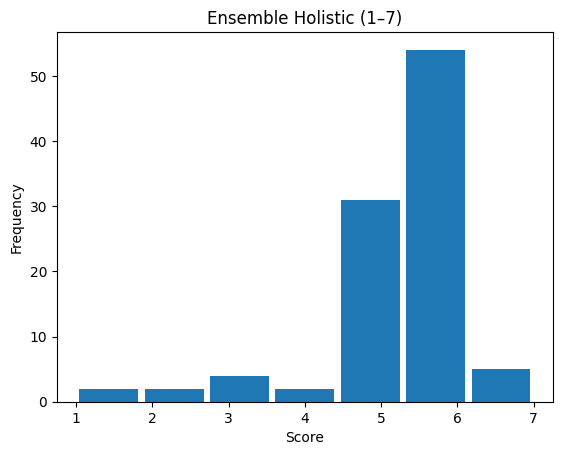

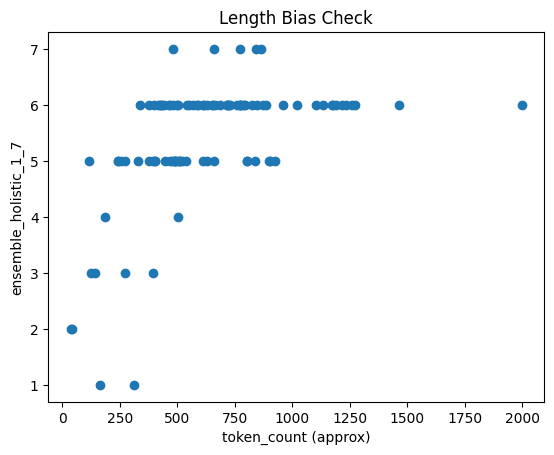

In [ ]:
import matplotlib.pyplot as plt

# Distribution of ensemble holistic
if "ensemble_holistic_1_7" in conv_df:
    plt.figure()
    conv_df["ensemble_holistic_1_7"].dropna().plot(kind="hist", bins=7, rwidth=0.9)
    plt.title("Ensemble Holistic (1–7)")
    plt.xlabel("Score")
    plt.show()

# Scatter: token_count vs ensemble holistic
if "token_count" in conv_df and "ensemble_holistic_1_7" in conv_df:
    plt.figure()
    plt.scatter(conv_df["token_count"], conv_df["ensemble_holistic_1_7"])
    plt.xlabel("token_count (approx)")
    plt.ylabel("ensemble_holistic_1_7")
    plt.title("Length Bias Check")
    plt.show()


## What success looks like (sanity expectations)

In [ ]:
from IPython.display import display

# 1) A few rows from each artifact
display(conv_df.sort_values("conversation_id").head(5))
display(judges_df.head(5))
display(ideas_df.head(5))

# 2) Key thresholds (tune for your paper)
OK_ICC     = 0.50   # moderate+ agreement
OK_LEN_RHO = 0.30   # abs correlation should be <= 0.3 (ideally near 0)

# Gate checks
reliability_flag = False
length_bias_flag = False

# Reliability: look for at least one decent ICC among main metrics
try:
    sr = [l for l in open(os.path.join(OUT_DIR,"sanity_report.txt")).read().splitlines() if "[Reliability]" in l]
    print("\n".join(sr[:10]))
except:
    pass

# Length bias flag (from report)
try:
    lr = [l for l in open(os.path.join(OUT_DIR,"sanity_report.txt")).read().splitlines() if "[Length Bias]" in l]
    print("\n".join(lr))
except:
    pass

print("\nArtifacts are in:", OUT_DIR)


,conversation_id,group,ensemble_holistic_1_7,ensemble_originality_1_7,ensemble_value_1_7,ensemble_insight_reframing_1_7,ensemble_development_1_7,ensemble_integration_1_7,ensemble_human_ethical_1_7,ensemble_process_evidence_1_7,judge_count,token_count,fluency_count,flexibility_count,is_anchor,warnings,fluency_1_7,flexibility_1_7
0,635,experiment group,3.0,3.0,4.0,3.0,3.0,3.0,4.0,3.0,5,272,2,2,False,social_psych: Evidence quote too long: 'what a...,1.0,2.0
1,937,experiment group,5.0,5.0,6.0,5.0,4.0,5.0,6.0,4.0,5,119,5,4,False,design_thinking: Evidence quote too long: 'bri...,2.0,4.0
2,939,experiment group,2.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,5,38,2,2,False,,1.0,2.0
3,941,experiment group,6.0,6.0,6.0,7.0,5.0,6.0,7.0,6.0,5,427,8,6,False,ethics: Evidence quote too long: 'not like tha...,3.0,5.0
4,943,control group,5.0,5.0,6.0,6.0,5.0,5.0,6.0,5.0,5,537,7,4,False,hci: Evidence quote too long: 'make that publi...,3.0,4.0


,conversation_id,group,persona_key,persona,originality_1_7,value_1_7,insight_reframing_1_7,development_1_7,integration_1_7,human_ethical_1_7,...,rat_originality,rat_value,rat_insight_reframing,rat_development,rat_integration,rat_human_ethical,rat_process_evidence,rat_overall,evidence_quotes,token_count
0,635,experiment group,design_thinking,Design Thinking Expert,3.0,4.0,3.0,3.0,2.0,4.0,...,The user asks standard questions about library...,The user focuses on practical constraints (bud...,Some reframing is attempted by identifying pai...,The user asks for elaboration and examples but...,Questions are somewhat scattered and do not sh...,The user considers the needs of young adults a...,There is evidence of divergent questioning and...,,what are some innovated ideas do you suggest?;...,272
1,635,experiment group,social_psych,Social Psychology Researcher,3.0,4.0,3.0,3.0,3.0,4.0,...,The user asks standard questions about library...,The user focuses on practical constraints (bud...,The user identifies pain points and constraint...,The user requests elaboration and examples but...,"Questions are somewhat connected (sound, desig...","The user considers user needs (quiet study, yo...",The user iteratively asks for more information...,,what are some innovated ideas do you suggest?;...,272
2,635,experiment group,hci,HCI Expert,4.0,5.0,4.0,3.0,4.0,5.0,...,The user asks for innovative ideas and referen...,The user focuses on practical constraints (bud...,The user reframes the problem by emphasizing q...,The user’s contributions are mostly follow-up ...,"The user connects spatial, acoustic, and scien...",The user is attentive to user needs (quiet stu...,"The user iteratively explores constraints, ask...",,what are some innovated ideas do you suggest?;...,272
3,635,experiment group,ethics,Philosopher/Ethicist,3.0,4.0,3.0,2.0,3.0,4.0,...,The user asks standard questions about library...,"The focus on practical constraints (budget, lo...",The user identifies pain points and asks for r...,Ideas are not elaborated; the user mostly requ...,Questions are loosely connected around sound a...,The user values quiet study spaces and accessi...,There is evidence of divergent questioning (sc...,,what are some innovated ideas; what are some c...,272
4,635,experiment group,innovation,Innovation/Strategy Expert,4.0,5.0,4.0,3.0,4.0,5.0,...,The user asks for innovative ideas and referen...,The user focuses on practical constraints (fix...,The user identifies the library's fixed nature...,The user asks for elaboration and examples but...,The user maintains a consistent focus on sound...,The user is attentive to user needs (quiet stu...,The user moves from problem identification to ...,,what are some innovated ideas do you suggest?;...,272


,conversation_id,group,idea_id,title,description
0,635,experiment group,I1,Use Irregular Room Shapes,Redesign library spaces with irregular room sh...
1,635,experiment group,I2,Target High-Noise Areas First,Prioritize sound-reducing interventions in spe...
2,937,experiment group,I1,Library Coffee Bar with Computers,"Create a library space combining computers, bo..."
3,937,experiment group,I2,Host Social Gaming Events,"Organize social gaming events in the library, ..."
4,937,experiment group,I3,Book-Related Movie Screenings,Screen movies based on books or related to lib...


[Reliability] holistic_creativity_1_7: ICC2k≈0.983 over 101 conv × 5 personas
[Reliability] originality_1_7: ICC2k≈0.983 over 101 conv × 5 personas
[Reliability] value_1_7: ICC2k≈0.984 over 101 conv × 5 personas
[Reliability] insight_reframing_1_7: ICC2k≈0.981 over 101 conv × 5 personas
[Reliability] development_1_7: ICC2k≈0.980 over 101 conv × 5 personas
[Reliability] integration_1_7: ICC2k≈0.981 over 101 conv × 5 personas
[Reliability] human_ethical_1_7: ICC2k≈0.978 over 101 conv × 5 personas
[Reliability] process_evidence_1_7: ICC2k≈0.982 over 101 conv × 5 personas
[Length Bias] Spearman(token_count, ensemble_holistic_1_7) = 0.543 (p=5.17e-09)

Artifacts are in: /content/creativity_out


## LLM as evaluater V1

Creativity Scores. We evaluated 101 user‑only transcripts using a five‑persona LLM ensemble. Ensemble Holistic ratings exhibited a strong ceiling effect: 90% of conversations scored ≥ 5 on a 1–7 scale (median = 6; 54% exactly 6). Sub‑scores were similarly top‑heavy, especially Value (74% at 6).

Length Sensitivity. We observed sizeable monotonic associations between transcript length and scores: Spearman( token_count, Holistic ) = 0.54, p < 1e‑7. Length correlated with all dimensions (ρ = 0.43–0.62), peaking for Development (ρ = 0.62). Transparency indices correlated as well (Fluency: ρ = 0.37; Flexibility: ρ = 0.37).

Pairwise Calibration. Latent Bradley–Terry (BT) scores from random A/B comparisons correlated with Ensemble Holistic (ρ = 0.56, p < 1e‑7), indicating convergent signal. However, BT also correlated with length (ρ = 0.61), suggesting pairwise preferences inherit verbosity bias.

Inter‑persona Reliability. On complete cases, ICC(2,k) was very high (0.94–0.98) and mean Kendall’s τ between persona rankings on Holistic was 0.79, but complete‑case coverage was limited (36/101 items for most metrics) and medians were uniformly high across personas (median = 6 for each), consistent with a shared leniency profile.

Operational Health. Evidence‑quote checks flagged formatting issues (363 “quote too long” warnings). Only one conversation had missing ensemble metrics after normalization; the remainder of missingness occurred at the persona level and was resolved by our schema harmonization step.

Threats to Validity.
(i) Leniency/Ceiling. The 1–7 rubric lacked calibrated anchor items; the model defaulted to high scores, compressing variance.
(ii) Verbosity Bias. Length and idea count explained substantial variance across dimensions; the instrument likely rewards elaboration beyond the point of sufficiency.
(iii) Rater Non‑independence. All personas rely on the same base LLM, inflating agreement and propagating shared biases.
(iv) Schema Drift. Removing structured outputs mid‑pipeline introduced missing values and warnings; we mitigated this by normalizing legacy JSON, but residual effects remain.
(v) Pairwise Spillover. A/B preference shares the same length bias and thus cannot serve as a bias‑free ground truth.
(vi) External Validity. Scores are LLM‑perceived creativity; without human‑normed calibration, their absolute levels should not be directly interpreted as human creativity.

Short “Method improvements” paragraph for the CHI paper

Bias‑aware Calibration. We upgraded the instrument with two safeguards. First, we introduced a set of human‑rated anchor transcripts spanning the full creativity range and learned an isotonic mapping from raw LLM scores to the human scale. Second, to mitigate verbosity bias we residualized each metric with respect to log transcript length and discretized residuals back to 1–7 using anchor cut‑points. We also strengthened rater independence by combining heterogeneous LLMs and a “critical” persona, enforced persona‑specific evidence quotes, and rejected scores lacking admissible evidence. Pairwise A/B comparisons were limited to length‑matched, within‑task pairs and used as a convergent‑validity check rather than as a primary estimator.

Methods—Structure‑Aware Evaluation of User Creativity in Co‑Creative Dialogues.
We evaluate user creativity in dialogues where the assistant frequently proposes ideas. Instead of rating raw text, we represent each conversation as a graph of idea threads with provenance (assistant vs. user origins) and extract User Creative Acts (U‑CAT)—selection, constraint/plan, reframing, extension, integration, and process‑direction—each supported by ≤12‑word user quotes. The judge scores the seven rubric dimensions from these acts under evidence gates (no quotes ⇒ max = 3; one weak quote ⇒ max = 4; 6–7 require multiple strong acts). To reduce leniency, we add three down‑only layers: an adversarial Critic (verbosity/genericness/feasibility checks), a domain‑specific Prior Bank (penalizing originality/development when user ideas mostly match familiar solutions unless extension is evidenced), and Anchor comparison (contrast to weak/strong exemplars). Across personas we aggregate with the 25th percentile. This design credits the user for novel extensions, coherent synthesis, constraint‑driven decisions, and actionable planning, rather than for assistant‑originated seeds. (Examples of assistant seeding and user extensions are visible in our transcripts.)

Threats & Mitigations.
Because assistants prime the space, originality can be inflated; we mitigate via provenance threads, act‑level evidence, prior penalties, and down‑only aggregation. Agreement among personas may be optimistic (shared model family); we therefore report NaN‑robust Q1 ensembles and calibrate to human‑rated anchors in a follow‑up.